# Decision Tree Algorithm

## What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm used for **classification** and **regression** tasks. It mimics **human decision-making** by learning rules inferred from data features.

Think of it like a **flowchart**:
- Each **internal node** represents a feature (attribute),
- Each **branch** represents a decision rule,
- Each **leaf node** represents an outcome (label).

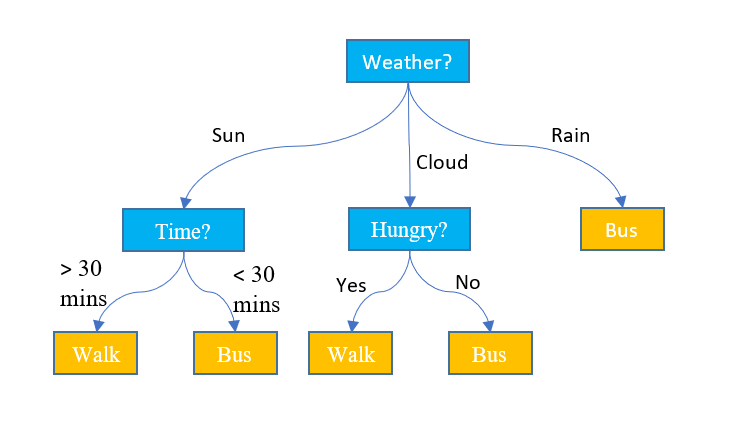

---


##  How Does It Work?

At its core, a decision tree:
1. **Splits the dataset** based on a feature that best separates the classes (or target values).
2. Continues recursively on the resulting subsets.
3. Stops when:
   - All instances in a node belong to the same class,
   - Or a maximum depth is reached,
   - Or further splitting does not reduce impurity.

---

##  Key Concepts

### 1. **Splitting Criteria**

To decide how to split data, the tree evaluates **impurity** or **information gain** using metrics like:

#### 🔸 Gini Impurity (for Classification)
- Measures how mixed the classes are.
- Range: 0 (pure, all items in one class) to 0.5 (mixed classes, 50/50 split)

#### 🔸 Entropy (Information Gain)

- Measures the randomness of the split.
- Range: 0 (pure) to 1 (maximum uncertainty).

#### 🔸 Mean Squared Error (MSE)
- Used in **regression** trees to measure variance in continuous values.



---
### 2. **Overfitting and Pruning**

Decision trees can easily **overfit**:
- They may memorize training data.

To avoid overfitting:
- **Pre-Pruning** (early stopping): Set max depth, min samples, etc.
- **Post-Pruning**: Build a full tree and prune branches using validation.



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
iris = sns.load_dataset('iris')

In [3]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [15]:
iris['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [16]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [50]:
label_encoder = LabelEncoder()
iris['Species']= label_encoder.fit_transform(iris['Species']) 

In [51]:
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [52]:
x=iris.drop(columns=['Species'])
y=iris['Species']

In [53]:
x

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [54]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64

In [55]:
x_train, x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=40)

### Building Decision Tree Classifier using Entropy Criteria

In [81]:
model = DecisionTreeClassifier(criterion = 'entropy',max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

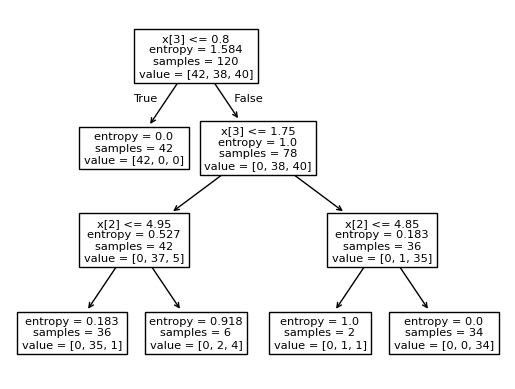

In [82]:
tree.plot_tree(model);

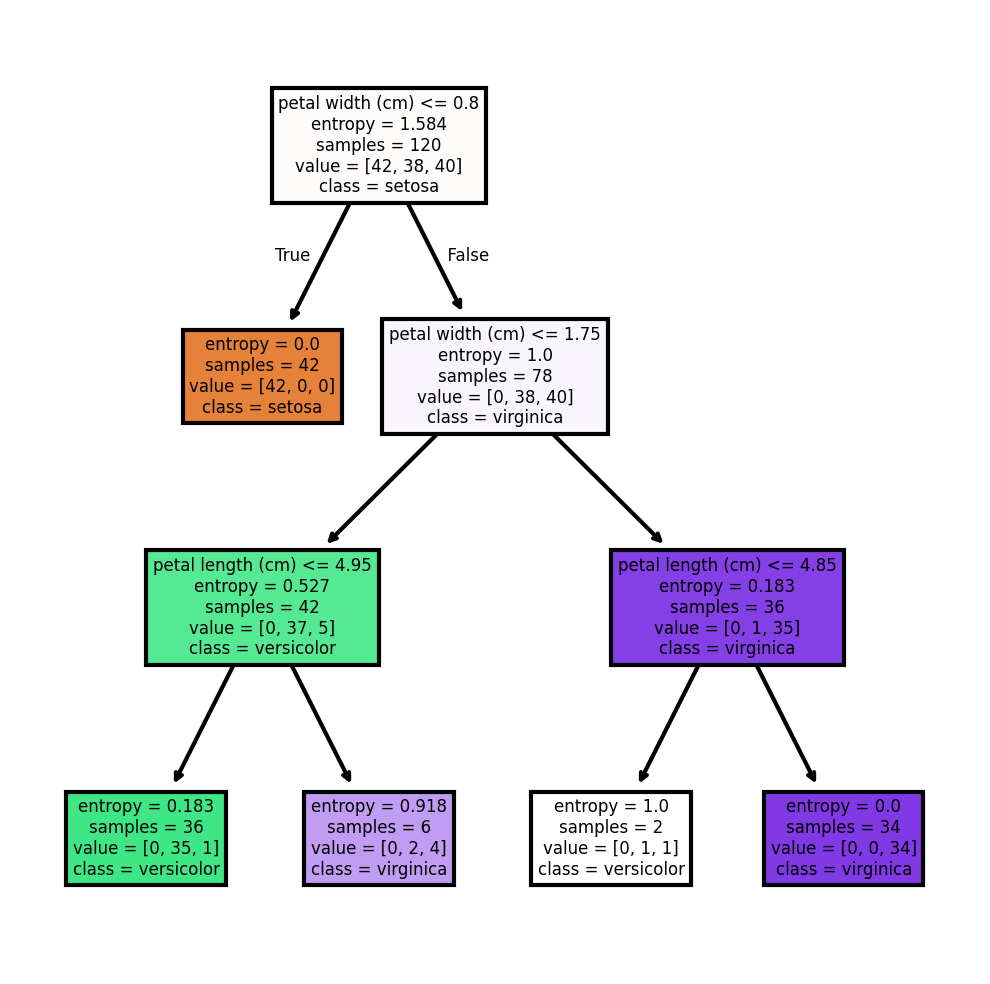

In [83]:
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa', 'versicolor', 'virginica']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(model,
               feature_names = fn, 
               class_names=cn,
               filled = True);

In [84]:
preds = model.predict(x_test) 
pd.Series(preds).value_counts() 

1    13
2     9
0     8
Name: count, dtype: int64

In [ ]:
preds 

array([0, 1, 2, 2, 1, 2, 1, 1, 1, 0, 1, 0, 0, 1, 1, 2, 2, 2, 1, 1, 2, 2,
       1, 0, 1, 0, 0, 2, 0, 1], dtype=int64)

In [86]:
pd.crosstab(y_test,preds) # getting the 2 way table to understand the correct and wrong predictions

col_0,0,1,2
Species,,,
0,8,0,0
1,0,12,0
2,0,1,9


In [87]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,preds))

0.9666666666666667


In [88]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.92      1.00      0.96        12
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Building Decision Tree Classifier using Gini Criteria

In [89]:
from sklearn.tree import DecisionTreeClassifier
model_gini = DecisionTreeClassifier(criterion='gini', max_depth=3)

In [90]:
model_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [91]:
#Prediction and computing the accuracy
pred=model_gini.predict(x_test)
np.mean(preds==y_test)

0.9666666666666667

#### Decision Tree Regression Example

In [92]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

In [93]:
array = iris.values
X = array[:,0:3]
y = array[:,3]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [95]:
model = DecisionTreeRegressor(criterion="squared_error")
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [96]:
ypred=model.predict(X_test)

In [97]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print("Mean Squared Error",mean_squared_error(ypred,y_test))
print("Mean Absolute Error",mean_absolute_error(ypred,y_test))
print("R2 Score",r2_score(ypred,y_test))

Mean Squared Error 0.0616
Mean Absolute Error 0.18
R2 Score 0.8908544537052787


In [ ]:
from sklearn.ensemble import RandomForestClassifier

